# Part 01 — Data and Graph Pipeline


The [PDBBind+](https://www.pdbbind-plus.org.cn) refined set provides `5316` experimentally measured protein-ligand binding affinities together with curated 3D complex structures, making it a standard benchmark for structure-based affinity prediction.

By the end of this notebook, we will have:
1. loaded a curated subset of PDBbind,
2. parsed ligand and pocket structures,
3. converted each protein-lignad complex into a PyTorch Geometric `HeteroData` object,
4. packaged the graphs into a dataset and dataloaders, and
5. run a compact EDA pass to verify the dataset looks sensible.

I have kept the processing choices fairly pragmatic here. The emphasis is on building a robust, readable pipeline that is easy to inspect and reuse in the training notebooks.

## 1. Imports and Configuration

Here I collect the core imports, file paths, and a few reusable constants. Keeping the configuration up front makes the rest of the notebook easier to follow and helps avoid scattered hard-coded values.

In [1]:
import os, re, gzip, tarfile, requests, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Draw import MolToImage

import Bio.PDB as PDB
from Bio.PDB import PDBParser, PDBIO

from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as PyGDataLoader

warnings.filterwarnings("ignore")

# ── Config ──────────────────────────────────────────────────────────────
DATA_DIR       = Path("../data")
PDBBIND_DIR    = DATA_DIR / "pdbbind"
PROCESSED_DIR  = DATA_DIR / "processed"
POCKET_CUTOFF  = 6.0   # Å — residues within this of any ligand atom = pocket
PROT_EDGE_CUTOFF = 8.0 # Å — Cα-Cα edges within protein
PL_EDGE_CUTOFF   = 5.0 # Å — protein-ligand interaction edges

DATA_DIR.mkdir(parents=True, exist_ok=True)
PDBBIND_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Torch: {torch.__version__}")
print(f"Data dir: {DATA_DIR.resolve()}")

Torch: 2.2.0
Data dir: /workspace/data


## 2. Load the PDBbind v2020 Refined Set

The refined set is available at `../data/pdbbind/refined-set/`. Each entry includes the protein structure, a pre-cropped binding pocket, and ligand files in standard cheminformatics formats.

For this prototype, I rely on `*_pocket.pdb` rather than the full protein because it keeps preprocessing faster and focuses the graph on the local interaction environment. For ligands, `*_ligand.sdf` is the cleanest starting point because bond information is already explicit.

To keep iteration manageable, I sample 150 complexes across the pKd range instead of taking a purely random slice. That gives us a more balanced view of weak, medium, and strong binders during training and evaluation.

The PDBbind index reports either `Kd` (dissociation constant) or `Ki` (inhibition constant), depending on what the original experiment measured. Lower `Kd`/`Ki` means tighter binding, while the `-logKd/Ki` column converts that value to a more model-friendly affinity label, so stronger binders have larger scores.


In [2]:
REFINED_SET_DIR = PDBBIND_DIR / "refined-set"
N_SAMPLE = 150  # complexes to use

def parse_pdbbind_index(index_path: Path) -> pd.DataFrame:
    # Format: PDB  resolution  year  -logKd  Kd/Ki=value  //  ref  (ligand)
    rows = []
    with open(index_path) as f:
        for line in f:
            line = line.strip()
            if line.startswith("#") or not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            try:
                rows.append({
                    "pdb_id":     parts[0].lower(),
                    "resolution": parts[1],
                    "year":       parts[2],
                    "neg_log_kd": float(parts[3]),
                    "exp_label":  parts[4],
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(rows)


def load_index_from_refined_set(refined_dir: Path) -> pd.DataFrame:
    candidates = [
        refined_dir / "index" / "INDEX_refined_data.2020",
        refined_dir / "INDEX_refined_data.2020",
        PDBBIND_DIR  / "index" / "INDEX_refined_data.2020",
        PDBBIND_DIR  / "INDEX_refined_data.2020",
    ]
    for p in candidates:
        if p.exists():
            df = parse_pdbbind_index(p)
            present = {d.name for d in refined_dir.iterdir() if d.is_dir()}
            df = df[df["pdb_id"].isin(present)].reset_index(drop=True)
            print(f"Index loaded from {p.name}: {len(df)} entries with structures")
            return df

    print("WARNING: no INDEX file found. Scanning folder names (no pKd labels).")
    pdb_ids = [d.name for d in sorted(refined_dir.iterdir()) if d.is_dir()]
    df = pd.DataFrame({"pdb_id": pdb_ids})
    df["neg_log_kd"] = 7.0
    df["year"] = "2020"; df["resolution"] = "2.0"; df["exp_label"] = "Kd"
    return df


def stratified_sample(df: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    """Sample n entries uniformly across pKd range — balanced coverage."""
    df = df.sort_values("neg_log_kd").reset_index(drop=True)
    indices = np.linspace(0, len(df) - 1, n, dtype=int)
    return df.iloc[indices].reset_index(drop=True)


# ── Load ──────────────────────────────────────────────────────────────────
assert REFINED_SET_DIR.exists(), f"refined-set not found at {REFINED_SET_DIR}"

df_full  = load_index_from_refined_set(REFINED_SET_DIR)
df_index = stratified_sample(df_full, N_SAMPLE)

print(f"\nFull refined set : {len(df_full)} complexes")
print(f"Sampled          : {len(df_index)} complexes")
print(f"pKd range        : {df_index['neg_log_kd'].min():.1f} – {df_index['neg_log_kd'].max():.1f}")
df_index.head()

Index loaded from INDEX_refined_data.2020: 5316 entries with structures

Full refined set : 5316 complexes
Sampled          : 150 complexes
pKd range        : 2.0 – 11.9


,pdb_id,resolution,year,neg_log_kd,exp_label
0,2r58,2.00,2007,2.00,Kd=10mM
1,1ew8,2.20,2002,2.26,Ki=5.5mM
2,4y4j,1.03,2016,2.47,Kd=3.4mM
3,4b3c,1.90,2013,2.68,Kd=2.1mM
4,3udh,1.70,2012,2.85,Kd=1.4mM


In [3]:
def get_complex_paths(pdb_id: str, refined_dir: Path) -> Optional[dict]:
    """
    Return paths to pocket PDB and ligand SDF for a PDBbind entry.
    Uses pre-cropped pocket (faster than full protein) and SDF (clean bonds).
    """
    entry_dir = refined_dir / pdb_id
    if not entry_dir.exists():
        return None
    pocket_pdb = entry_dir / f"{pdb_id}_pocket.pdb"
    ligand_sdf = entry_dir / f"{pdb_id}_ligand.sdf"
    ligand_mol2 = entry_dir / f"{pdb_id}_ligand.mol2"
    if not pocket_pdb.exists():
        return None
    if not ligand_sdf.exists() and not ligand_mol2.exists():
        return None
    return {
        "pocket_pdb":  pocket_pdb,
        "ligand_sdf":  ligand_sdf  if ligand_sdf.exists()  else None,
        "ligand_mol2": ligand_mol2 if ligand_mol2.exists() else None,
    }


# Verify all 150 sampled entries exist locally
paths = {}
missing = []
for pdb_id in df_index["pdb_id"]:
    p = get_complex_paths(pdb_id, REFINED_SET_DIR)
    if p:
        paths[pdb_id] = p
    else:
        missing.append(pdb_id)

print(f"Found : {len(paths)}/{len(df_index)} complexes")
if missing:
    print(f"Missing: {missing[:10]}{'...' if len(missing)>10 else ''}")
else:
    print("All 150 present locally — no download needed.")

Found : 150/150 complexes
All 150 present locally — no download needed.


## 3. Featurization

The feature design in this notebook is deliberately simple and chemically interpretable. I am not trying to handcraft an exhaustive descriptor set; instead, I want enough signal for the model to distinguish atom types, residue identities, and the local geometry of the pocket.

### 4.1 Ligand atom features
| Feature | Encoding |
|---------|----------|
| Atomic number | one-hot (H, C, N, O, F, P, S, Cl, Br, I, plus other) |
| Degree | one-hot (0-5) |
| Hybridization | one-hot (SP, SP2, SP3, SP3D, SP3D2) |
| Formal charge | integer |
| Is in ring | boolean |
| Is aromatic | boolean |
| Hydrogen count | integer |

### 4.2 Protein residue features
| Feature | Encoding |
|---------|----------|
| Amino acid type | one-hot (20 standard amino acids) |
| Backbone atom presence | 4 booleans for N / CA / C / O |
| SASA proxy (relative) | float |
| Hydrophobicity | float (Kyte-Doolittle scale) |

### 4.3 Edge features
| Edge type | Features |
|-----------|---------|
| Ligand bond | bond type one-hot, distance |
| Protein Cα-Cα contact | distance |
| Protein-ligand interaction | distance, donor/acceptor interaction flags |

These are not the only reasonable choices, but they strike a good balance between expressiveness and implementation complexity for a take-home prototype.

In [4]:
from rdkit.Chem import rdchem

# ── Lookup tables ────────────────────────────────────────────────────────
ATOM_TYPES   = ["H","C","N","O","F","P","S","Cl","Br","I"]
DEGREES      = [0, 1, 2, 3, 4, 5]
HYBRIDIZE    = [
    rdchem.HybridizationType.SP,
    rdchem.HybridizationType.SP2,
    rdchem.HybridizationType.SP3,
    rdchem.HybridizationType.SP3D,
    rdchem.HybridizationType.SP3D2,
]
BOND_TYPES   = [
    rdchem.BondType.SINGLE,
    rdchem.BondType.DOUBLE,
    rdchem.BondType.TRIPLE,
    rdchem.BondType.AROMATIC,
]
AA_TYPES = [
    "ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS","ILE",
    "LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"
]
KD_SCALE = {
    "ILE":4.5,"VAL":4.2,"LEU":3.8,"PHE":2.8,"CYS":2.5,"MET":1.9,
    "ALA":1.8,"GLY":-0.4,"THR":-0.7,"SER":-0.8,"TRP":-0.9,"TYR":-1.3,
    "PRO":-1.6,"HIS":-3.2,"GLU":-3.5,"GLN":-3.5,"ASP":-3.5,"ASN":-3.5,
    "LYS":-3.9,"ARG":-4.5
}

def one_hot(val, choices, allow_unknown=True):
    vec = [int(val == c) for c in choices]
    if allow_unknown:
        vec.append(int(val not in choices))
    return vec

def featurize_ligand_atom(atom) -> List[float]:
    sym = atom.GetSymbol()
    return (
        one_hot(sym, ATOM_TYPES)                          # 11
        + one_hot(atom.GetDegree(), DEGREES)              # 7
        + one_hot(atom.GetHybridization(), HYBRIDIZE)     # 6
        + [atom.GetFormalCharge(),                        # 1
           int(atom.IsInRing()),                          # 1
           int(atom.GetIsAromatic()),                     # 1
           atom.GetTotalNumHs()]                          # 1
    )  # total dim = 28

def featurize_ligand_bond(bond) -> List[float]:
    return (
        one_hot(bond.GetBondType(), BOND_TYPES, allow_unknown=False)  # 4
        + [int(bond.IsInRing()), int(bond.GetIsAromatic())]           # 2
    )  # dim = 6 (+ distance appended later)

def featurize_residue(res) -> List[float]:
    res_name = res.get_resname().strip()
    atom_names = [a.get_name() for a in res.get_atoms()]
    return (
        one_hot(res_name, AA_TYPES)                          # 21 (20 AA + unknown)
        + [int("N"  in atom_names),                          # 1
           int("CA" in atom_names),                          # 1
           int("C"  in atom_names),                          # 1
           int("O"  in atom_names),                          # 1
           KD_SCALE.get(res_name, 0.0) / 4.5]               # 1
    )  # total dim = 26

LIGAND_NODE_DIM  = 28
PROTEIN_NODE_DIM = 26   # 21 AA one-hot (20 + unknown) + 4 backbone flags + 1 hydrophobicity

print(f"Ligand node dim:  {LIGAND_NODE_DIM}")
print(f"Protein node dim: {PROTEIN_NODE_DIM}")

Ligand node dim:  28
Protein node dim: 26


## 4. Graph Construction — `HeteroData`

This is the core of Phase 1. Each protein-ligand complex is converted into a heterogeneous graph with two node types, `ligand` and `residue`, and three explicit edges types: ligand-ligand bonds, residue-residue contacts, and residue-ligand interactions.

In practice, ligand atoms from the RDKit conformer become `ligand` nodes. Protein residues are included as `residue` nodes when any of their atoms lie within `POCKET_CUTOFF = 6A` of the ligand, which defines the local binding pocket. We then add ligand bond edges from the molecular structure, residue-residue contact edges between nearby C-alpha coordinates using `PROT_EDGE_CUTOFF = 8A`, and residue-ligand interaction edges for close pairs within `PL_EDGE_CUTOFF = 5A`. These cross-edges store geometric features such as distance, along with simple donor/acceptor interaction flags.

This separation is important because it preserves the distinction between ligand chemistry and protein pocket context while still allowing the model to learn how they interact within a single `HeteroData` graph.

In [5]:
from scipy.spatial.distance import cdist

HBOND_DONORS    = {"N", "O"}
HBOND_ACCEPTORS = {"N", "O", "F"}

def get_ca_coords(residues):
    coords = []
    for res in residues:
        if "CA" in res:
            coords.append(res["CA"].get_vector().get_array())
        else:
            atoms = list(res.get_atoms())
            if atoms:
                coords.append(np.mean([a.get_vector().get_array() for a in atoms], axis=0))
            else:
                coords.append(np.zeros(3))
    return np.array(coords, dtype=np.float32)


def _normalise_mol(mol: Chem.Mol) -> Optional[Chem.Mol]:
    """
    Normalise mol valence via AddHs/RemoveHs round-trip.
    Falls back to original mol if AddHs fails (e.g. non-kekulized aromatics).
    """
    if mol.GetNumConformers() == 0:
        return None
    try:
        mol_h = Chem.AddHs(mol, addCoords=True)
        mol   = Chem.RemoveHs(mol_h)
    except Exception:
        pass  # keep mol as-is with original conformer
    if mol.GetNumConformers() == 0:
        return None
    return mol


def pdb_to_hetero_graph(
    pdb_path: Path,
    mol: Chem.Mol,
    label_pkd: float,
    label_pose: float = 0.0,
    label_select: float = 0.0,
) -> Optional[HeteroData]:
    """
    Build heterogeneous graph from pocket PDB + RDKit mol (from SDF).

    Node types:  'ligand', 'residue'
    Edge types:
        ('ligand',  'bond',      'ligand')  — covalent bonds
        ('residue', 'contact',   'residue') — Cα-Cα < PROT_EDGE_CUTOFF
        ('residue', 'interacts', 'ligand')  — pocket residue ↔ ligand < PL_EDGE_CUTOFF
        ('ligand',  'interacts', 'residue') — reverse
    """
    mol = _normalise_mol(mol)
    if mol is None:
        return None

    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure("X", str(pdb_path))
    except Exception:
        return None
    model = next(structure.get_models())

    conf = mol.GetConformer()
    lig_coords = np.array(
        [conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())],
        dtype=np.float32,
    )

    # ── Get pocket residues (ATOM records only, standard AA) ─────────────
    all_res = [
        r for r in model.get_residues()
        if r.id[0] == " " and r.get_resname().strip() in AA_TYPES
    ]
    pocket_residues = []
    for res in all_res:
        res_atoms = list(res.get_atoms())
        if not res_atoms:
            continue
        res_coords = np.array([a.get_vector().get_array() for a in res_atoms])
        if cdist(res_coords, lig_coords).min() <= POCKET_CUTOFF:
            pocket_residues.append(res)

    if len(pocket_residues) < 3:
        return None

    # ── Node features ────────────────────────────────────────────────────
    x_lig  = torch.tensor([featurize_ligand_atom(a) for a in mol.GetAtoms()], dtype=torch.float)
    x_prot = torch.tensor([featurize_residue(r)     for r in pocket_residues], dtype=torch.float)

    # ── Ligand bond edges ────────────────────────────────────────────────
    lig_src, lig_dst, lig_eatts = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        ef   = featurize_ligand_bond(bond)
        dist = float(np.linalg.norm(lig_coords[i] - lig_coords[j]))
        lig_src += [i, j];  lig_dst += [j, i]
        lig_eatts += [ef + [dist], ef + [dist]]

    # ── Protein Cα-Cα edges ──────────────────────────────────────────────
    ca_coords = get_ca_coords(pocket_residues)
    D_prot = cdist(ca_coords, ca_coords)
    pi, pj = np.where((D_prot > 0) & (D_prot <= PROT_EDGE_CUTOFF))
    prot_src   = pi.tolist(); prot_dst   = pj.tolist()
    prot_eatts = [[float(D_prot[i, j])] for i, j in zip(pi, pj)]

    # ── Protein-Ligand interaction edges ─────────────────────────────────
    pl_src_p, pl_dst_l, pl_eatts = [], [], []
    lp_src_l, lp_dst_p, lp_eatts = [], [], []
    D_pl = cdist(ca_coords, lig_coords)
    pi2, li2 = np.where(D_pl <= PL_EDGE_CUTOFF)
    for p_idx, l_idx in zip(pi2, li2):
        dist = float(D_pl[p_idx, l_idx])
        la   = mol.GetAtomWithIdx(int(l_idx))
        ef   = [dist, int(la.GetSymbol() in HBOND_DONORS), int(la.GetSymbol() in HBOND_ACCEPTORS)]
        pl_src_p.append(int(p_idx)); pl_dst_l.append(int(l_idx)); pl_eatts.append(ef)
        lp_src_l.append(int(l_idx)); lp_dst_p.append(int(p_idx)); lp_eatts.append(ef)

    # ── Assemble HeteroData ───────────────────────────────────────────────
    data = HeteroData()
    data["ligand"].x    = x_lig
    data["ligand"].pos  = torch.tensor(lig_coords, dtype=torch.float)
    data["residue"].x   = x_prot
    data["residue"].pos = torch.tensor(ca_coords,  dtype=torch.float)

    ei = lambda s, d: torch.tensor([s, d], dtype=torch.long) if s else torch.zeros((2, 0), dtype=torch.long)

    data["ligand",  "bond",      "ligand" ].edge_index = ei(lig_src,  lig_dst)
    data["ligand",  "bond",      "ligand" ].edge_attr  = torch.tensor(lig_eatts,  dtype=torch.float) if lig_eatts  else torch.zeros((0, 7))
    data["residue", "contact",   "residue"].edge_index = ei(prot_src, prot_dst)
    data["residue", "contact",   "residue"].edge_attr  = torch.tensor(prot_eatts, dtype=torch.float) if prot_eatts else torch.zeros((0, 1))
    data["residue", "interacts", "ligand" ].edge_index = ei(pl_src_p, pl_dst_l)
    data["residue", "interacts", "ligand" ].edge_attr  = torch.tensor(pl_eatts,   dtype=torch.float) if pl_eatts   else torch.zeros((0, 3))
    data["ligand",  "interacts", "residue"].edge_index = ei(lp_src_l, lp_dst_p)
    data["ligand",  "interacts", "residue"].edge_attr  = torch.tensor(lp_eatts,   dtype=torch.float) if lp_eatts   else torch.zeros((0, 3))

    data.y_affinity = torch.tensor([label_pkd],    dtype=torch.float)
    data.y_pose     = torch.tensor([label_pose],   dtype=torch.float)
    data.y_select   = torch.tensor([label_select], dtype=torch.float)
    data.pdb_id     = pdb_path.stem
    return data


print("Graph builder ready.")

Graph builder ready.


## 5. Load Ligand Structures

This helper step loads the ligand structure that will be paired with each pocket during graph construction. The pipeline prefers SDF because bond orders and coordinates are already present, and falls back to mol2 when needed.

In [6]:
def get_ligand_mol_from_sdf(sdf_path: Path) -> Optional[Chem.Mol]:
    """
    Load ligand from PDBbind SDF.
    Tries strict sanitization first; falls back to partial (skip kekulize)
    for older SDFs with non-standard aromatic encoding.
    """
    for sanitize in (True, False):
        suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=True, sanitize=sanitize)
        for mol in suppl:
            if mol is None:
                continue
            if not sanitize:
                try:
                    # skip kekulization — aromatic bonds already encoded in SDF
                    Chem.SanitizeMol(
                        mol,
                        Chem.SanitizeFlags.SANITIZE_ALL
                        ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE
                    )
                    mol.UpdatePropertyCache(strict=False)
                except Exception:
                    continue
            if mol.GetNumAtoms() > 1 and mol.GetNumConformers() > 0:
                return mol
    return None


def get_ligand_mol_from_mol2(mol2_path: Path) -> Optional[Chem.Mol]:
    """Fallback: load from mol2 (explicit bond types survive kekulize issues)."""
    for sanitize in (True, False):
        try:
            mol = Chem.MolFromMol2File(str(mol2_path), removeHs=True, sanitize=sanitize)
            if mol is None:
                continue
            if not sanitize:
                try:
                    Chem.SanitizeMol(
                        mol,
                        Chem.SanitizeFlags.SANITIZE_ALL
                        ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE
                    )
                    mol.UpdatePropertyCache(strict=False)
                except Exception:
                    continue
            if mol.GetNumAtoms() > 1 and mol.GetNumConformers() > 0:
                return mol
        except Exception:
            continue
    return None


def get_ligand_mol(complex_paths: dict) -> Optional[Chem.Mol]:
    """SDF (strict → relaxed) → mol2 (strict → relaxed) → None."""
    if complex_paths.get("ligand_sdf"):
        mol = get_ligand_mol_from_sdf(complex_paths["ligand_sdf"])
        if mol:
            return mol
    if complex_paths.get("ligand_mol2"):
        return get_ligand_mol_from_mol2(complex_paths["ligand_mol2"])
    return None


# ── Test on first entry ───────────────────────────────────────────────────
first_id = df_index["pdb_id"].iloc[0]
first_paths = paths.get(first_id)
if first_paths:
    mol_test = get_ligand_mol(first_paths)
    if mol_test:
        print(f"{first_id} ligand: {mol_test.GetNumAtoms()} atoms, {mol_test.GetNumConformers()} conformers")
        print(f"SMILES: {Chem.MolToSmiles(mol_test)[:80]}")
    else:
        print(f"Could not load ligand for {first_id}")
else:
    print(f"{first_id} not in paths")

2r58 ligand: 12 atoms, 1 conformers
SMILES: C[NH+](C)CCCC[C@H]([NH3+])C(=O)O


[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


## 6. Build the Full Dataset

In [7]:
import torch
from torch.utils.data import Dataset

class PDBBindDataset(Dataset):
    def __init__(self, df, complex_paths, processed_dir, force_rebuild=False):
        self.graphs = []
        self._build(df, complex_paths, processed_dir, force_rebuild)

    def _build(self, df, complex_paths, processed_dir, force_rebuild):
        cache_path = processed_dir / "dataset.pt"
        if cache_path.exists() and not force_rebuild:
            print(f"Loading cached dataset from {cache_path}")
            self.graphs = torch.load(cache_path, weights_only=False)
            print(f"  {len(self.graphs)} graphs loaded.")
            return

        print(f"Building {len(df)} graphs from PDBbind refined set...")
        failed = 0
        median_pkd = df["neg_log_kd"].median()

        for _, row in tqdm(df.iterrows(), total=len(df)):
            pdb_id = row["pdb_id"]
            pkd    = float(row["neg_log_kd"])
            cpaths = complex_paths.get(pdb_id)
            if cpaths is None:
                failed += 1; continue
            mol = get_ligand_mol(cpaths)
            if mol is None:
                failed += 1; continue
            pose_label = 1.0 if pkd >= median_pkd else 0.0
            graph = pdb_to_hetero_graph(
                cpaths["pocket_pdb"], mol, pkd,
                label_pose=pose_label, label_select=0.0
            )
            if graph is not None:
                self.graphs.append(graph)
            else:
                failed += 1

        print(f"Built {len(self.graphs)} graphs. Failed/skipped: {failed}")
        torch.save(self.graphs, cache_path)
        print(f"Cached to {cache_path}")

    def __len__(self):  return len(self.graphs)
    def __getitem__(self, idx): return self.graphs[idx]


# force_rebuild=True to pick up bug fixes
dataset = PDBBindDataset(df_index, paths, PROCESSED_DIR, force_rebuild=True)
print(f"\nDataset size: {len(dataset)}")
if len(dataset) > 0:
    g = dataset[0]
    print(f"\nSample graph [{g.pdb_id}]:")
    print(f"  ligand nodes : {g['ligand'].x.shape}")
    print(f"  residue nodes: {g['residue'].x.shape}")
    print(f"  lig bonds    : {g['ligand','bond','ligand'].edge_index.shape}")
    print(f"  prot contacts: {g['residue','contact','residue'].edge_index.shape}")
    print(f"  PL edges     : {g['residue','interacts','ligand'].edge_index.shape}")
    print(f"  y_affinity   : {g.y_affinity.item():.2f}")

Building 150 graphs from PDBbind refined set...


  0%|          | 0/150 [00:00<?, ?it/s]

[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:14] ERROR: Could not sanitize molecule ending on line 38
[18:19:14] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:14] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9


[18:19:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:15] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:15] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


[18:19:15] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:15] ERROR: Could not sanitize molecule ending on line 56
[18:19:15] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:15] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:15] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:15] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:15] Can't kekulize mol.  Unkekulized atoms: 1 2 3 5 6 7 8 9 10
[18:19:15] ERROR: Could not sanitize molecule ending on line 36
[18:19:15] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 5 6 7 8 9 10
[18:19:15] Warning: molecule is tagged as 2D, but at least one 

...

[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 12 13 14 15 16 17
[18:19:17] ERROR: Could not sanitize molecule ending on line 101
[18:19:17] ERROR: Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 11 12 13 14 15 16 17
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marki

[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


Built 150 graphs. Failed/skipped: 0
Cached to ../data/processed/dataset.pt

Dataset size: 150

Sample graph [2r58_pocket]:
  ligand nodes : torch.Size([12, 28])
  residue nodes: torch.Size([9, 26])
  lig bonds    : torch.Size([2, 22])
  prot contacts: torch.Size([2, 30])
  PL edges     : torch.Size([2, 0])
  y_affinity   : 2.00


## 7. Train / Validation / Test Split and DataLoaders

After graph construction, the dataset is divided into train, validation, and test subsets so model development and final evaluation stay separate. The training split is used to fit model parameters, the validation split is used to monitor performance and tune choices such as hyperparameters, and the test split is kept untouched until the end for unbiased assessment of generalization.

In [8]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader as PyGLoader

def make_splits(dataset, train_frac=0.8, val_frac=0.1, seed=42):
    n = len(dataset)
    idx = list(range(n))
    train_idx, temp_idx = train_test_split(idx, test_size=1-train_frac, random_state=seed)
    val_idx,  test_idx  = train_test_split(temp_idx,
                                            test_size=val_frac/(1-train_frac),
                                            random_state=seed)
    return (
        [dataset[i] for i in train_idx],
        [dataset[i] for i in val_idx],
        [dataset[i] for i in test_idx],
    )

if len(dataset) >= 5:
    train_data, val_data, test_data = make_splits(dataset)
    print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

    BATCH_SIZE = 4
    train_loader = PyGLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = PyGLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = PyGLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

    # Quick batch check
    batch = next(iter(train_loader))
    print(f"\nBatch ligand x shape : {batch['ligand'].x.shape}")
    print(f"Batch residue x shape: {batch['residue'].x.shape}")
    print(f"y_affinity batch     : {batch.y_affinity.squeeze()}")
else:
    print(f"Only {len(dataset)} graphs — need ≥5 for splitting. Run PDB fetch first.")

Train: 120 | Val: 14 | Test: 16

Batch ligand x shape : torch.Size([78, 28])
Batch residue x shape: torch.Size([104, 26])
y_affinity batch     : tensor([8.8900, 7.4900, 4.7400, 2.4700])


## 8. Sanity Checks and Exploratory Analysis

Before training the GNN, it is useful to verify that the cached graphs cover a reasonable range of affinities, ligand sizes, pocket sizes, and protein-ligand interaction counts. The figure below uses a restrained manuscript-style layout so the same view can be reused in reports or slides with minimal cleanup.

[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:18] ERROR: Could not sanitize molecule ending on line 38
[18:19:18] ERROR: Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 8 9
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:18] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:

[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] Can't kekulize mol.  Unkekulized atoms: 5 24 25 26 27
[18:19:19] ERROR: Could not sanitize molecule ending on line 101
[18:19:19] ERROR: Can't kekulize mol.  Unkekulized atoms: 5 24 25 26 27
[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:19:19] War

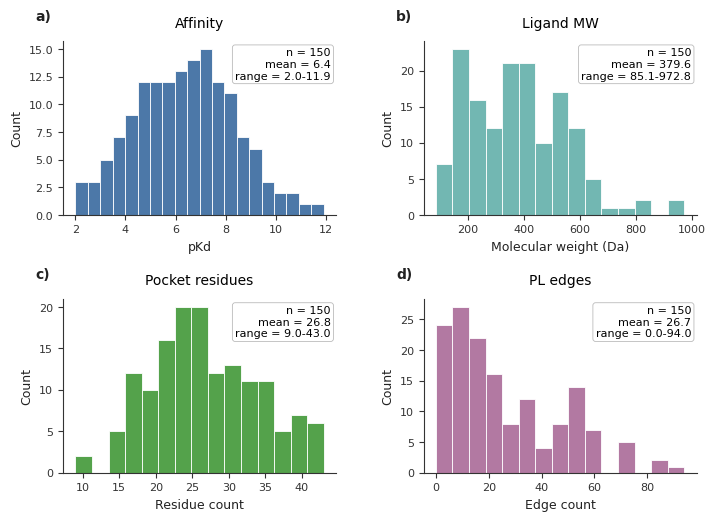

Saved Nature-style EDA figure to ../data/processed/eda_nature.png


In [9]:
if len(dataset) == 0:
    print("No graphs built yet. Run the dataset build cell first.")
else:
    pkds = np.array([g.y_affinity.item() for g in dataset], dtype=float)
    ligand_mws = []
    for g in dataset:
        base_pdb_id = g.pdb_id.replace("_pocket", "")
        cpaths = paths.get(base_pdb_id)
        mol = get_ligand_mol(cpaths) if cpaths is not None else None
        ligand_mws.append(float(Descriptors.MolWt(mol)) if mol is not None else np.nan)
    ligand_mws = np.array(ligand_mws, dtype=float)
    n_residues = np.array([g["residue"].x.shape[0] for g in dataset], dtype=int)
    n_pl_edges = np.array([g["residue", "interacts", "ligand"].edge_index.shape[1] for g in dataset], dtype=int)

    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#222222",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    })

    fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.4))
    fig.patch.set_facecolor("white")

    panels = [
        (axes[0, 0], pkds, 20, "#4C78A8", "Affinity", "pKd"),
        (axes[0, 1], ligand_mws, 15, "#72B7B2", "Ligand MW", "Molecular weight (Da)"),
        (axes[1, 0], n_residues, 15, "#54A24B", "Pocket residues", "Residue count"),
        (axes[1, 1], n_pl_edges, 15, "#B279A2", "PL edges", "Edge count"),
    ]

    for idx, (ax, values, bins, color, title, xlabel) in enumerate(panels):
        values = np.asarray(values, dtype=float)
        plot_values = values[np.isfinite(values)]
        ax.hist(plot_values, bins=bins, color=color, edgecolor="#FFFFFF", linewidth=0.6)
        ax.set_title(title, pad=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if len(plot_values) == 0:
            stats_text = "n = 0\nmean = n/a\nrange = n/a"
        else:
            stats_text = (
                f"n = {len(plot_values)}\n"
                f"mean = {np.mean(plot_values):.1f}\n"
                f"range = {np.min(plot_values):.1f}-{np.max(plot_values):.1f}"
            )
        ax.text(
            0.98, 0.96, stats_text,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", linewidth=0.6),
        )
        ax.text(
            -0.10, 1.10, f"{chr(97 + idx)})",
            transform=ax.transAxes, ha="left", va="bottom",
            fontsize=10, fontweight="bold", color="#222222"
        )

    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.10, top=0.90, wspace=0.32, hspace=0.48)
    out_path = PROCESSED_DIR / "eda_nature.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved Nature-style EDA figure to {out_path}")


## Summary

At this point the structural preprocessing pipeline is in place and the graph dataset is ready for modelling.

| Artifact | Location |
|----------|----------|
| Raw PDB structures | `../data/pdbbind/structures/*.pdb` |
| Cached graphs | `../data/processed/dataset.pt` |
| Nature-style EDA plot | `../data/processed/eda_nature.png` |
| Train / val / test loaders | created in-memory in this notebook |

The next notebook takes these graphs and trains the structure-aware GNN used as the scoring model for the rest of the project.